shape of s: (10000, 2)
shape of dataset: torch.Size([10000, 2])


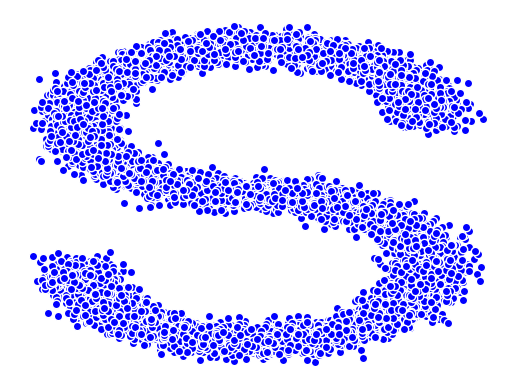

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_s_curve
import torch

s_curve,_ = make_s_curve(10**4,noise=0.1)
# make 3D to 2D data
s_curve = s_curve[:, [0,2]] / 10.0
print("shape of s:",np.shape(s_curve))

fig,ax = plt.subplots()
ax.scatter(*s_curve.T,color='blue',edgecolor='white')
ax.axis('off')

dataset = torch.Tensor(s_curve).float()
print("shape of dataset:", dataset.shape)

2、确定超参数的值

In [2]:
num_steps = 100

#制定每一步的beta
betas = torch.linspace(-6, 6, num_steps)
betas = torch.sigmoid(betas) * (0.5e-2 - 1e-5) + 1e-5

#计算alpha、alpha_prod、alpha_prod_previous、alpha_bar_sqrt等变量的值
alphas = 1 - betas
alphas_prod = torch.cumprod(alphas, 0) # alpha_bar
alphas_prod_p = torch.cat([torch.tensor([1]).float(), alphas_prod[:-1]], 0)
alphas_bar_sqrt = torch.sqrt(alphas_prod)
one_minus_alphas_bar_log = torch.log(1 - alphas_prod)
one_minus_alphas_bar_sqrt = torch.sqrt(1 - alphas_prod)

assert alphas.shape==alphas_prod.shape==alphas_prod_p.shape==\
alphas_bar_sqrt.shape==one_minus_alphas_bar_log.shape\
==one_minus_alphas_bar_sqrt.shape
print("all the same shape",betas.shape)

all the same shape torch.Size([100])


3、确定扩散过程任意时刻的采样值

In [3]:
#计算任意时刻的x采样值，基于x_0和重参数化
def q_x(x_0, t):
    """q(xt|x0)"""
    noise = torch.randn_like(x_0)
    alphas_t = alphas_bar_sqrt[t]
    alphas_1_m_t = one_minus_alphas_bar_sqrt[t]
    return (alphas_t * x_0 + alphas_1_m_t * noise)
    

4、演示原始数据分布加噪100步后的结果

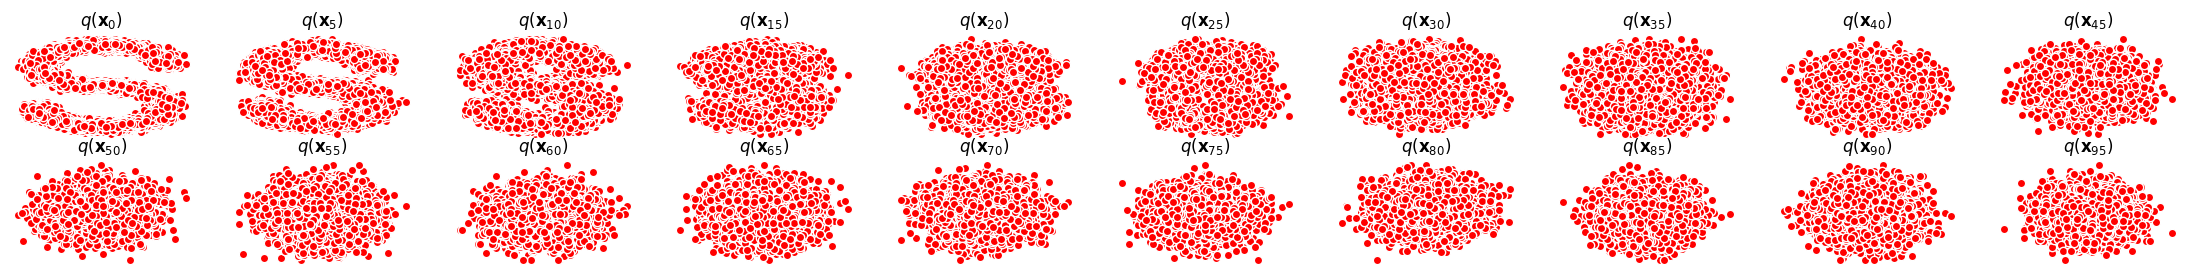

In [4]:
num_shows = 20
fig,axs = plt.subplots(2, 10, figsize=(28,3))
plt.rc('text', color='black')

#共有10000个点，每个点包含两个坐标
#生成100步以内每隔5步加噪声后的图像
for i in range(num_shows):
    j = i // 10
    k = i % 10
    q_i = q_x(dataset, torch.tensor([i * num_steps//num_shows]))# 生成t时刻的采样数据
    axs[j,k].scatter(q_i[:,0], q_i[:,1], color='red', edgecolor='white')
    axs[j,k].set_axis_off()
    axs[j,k].set_title('$q(\mathbf{x}_{'+str(i*num_steps//num_shows)+'})$')

5、编写拟合逆扩散过程高斯分布的模型

In [5]:
import torch
import torch.nn as nn

class MLPDiffusion(nn.Module):
    def __init__(self, n_steps, num_units=128):
        super(MLPDiffusion,self).__init__()
        
        self.linears = nn.ModuleList(
            [
                nn.Linear(2, num_units), # 2 -> 128
                nn.ReLU(),
                nn.Linear(num_units, num_units), # 128 -> 128
                nn.ReLU(),
                nn.Linear(num_units, num_units), # 128 -> 128
                nn.ReLU(),
                nn.Linear(num_units, 2), # 128 -> 2
            ]
        )
        self.step_embeddings = nn.ModuleList(
            [
                nn.Embedding(n_steps, num_units),
                nn.Embedding(n_steps, num_units),
                nn.Embedding(n_steps, num_units),
            ]
        )
    def forward(self, x, t):
        for idx, embedding_layer in enumerate(self.step_embeddings):
            t_embedding = embedding_layer(t)
            x = self.linears[2 * idx](x) # Linear()
            x += t_embedding
            x = self.linears[2 * idx + 1](x) # Relu()
            
        x = self.linears[-1](x)
        
        return x

6、编写训练的误差函数

In [6]:
def diffusion_loss_fn(epsilon_theta, x_0, alphas_bar_sqrt, one_minus_alphas_bar_sqrt, n_steps):
    """对任意时刻t进行采样计算loss"""
    batch_size = x_0.shape[0]
    
    #对一个batchsize样本生成随机的时刻t
    """
    t_random = [ 23, 114, 600, 800 ]
    mirror    = [ 976, 885, 399, 199 ]
    final_t   = [ 23, 114, 600, 800, 976, 885, 399, 199 ]

    The mirror trick ensures each batch sees:
    1. both easy denoising (small t) examples, and
    2. hard denoising (large t) examples.
    """
    t = torch.randint(0, n_steps, size=(batch_size // 2,))
    t = torch.cat([t, n_steps - 1 - t], dim=0)
    t = t.unsqueeze(-1) # from [batch_size] to [batch_size, 1]
    
    #生成随机噪音eps
    epsilon = torch.randn_like(x_0)
    
    #构造模型的输入
    xt = alphas_bar_sqrt[t] * x_0 + one_minus_alphas_bar_sqrt[t] * epsilon
    
    #送入模型，得到t时刻的随机噪声预测值
    output = epsilon_theta(xt, t.squeeze(-1)) # from [batch_size, 1] to [batch_size]
    
    #与真实噪声一起计算误差，求平均值
    return (epsilon - output).square().mean()

7、编写逆扩散采样函数（inference）

In [7]:
def p_sample_loop(model, shape, n_steps, betas, one_minus_alphas_bar_sqrt):
    """从x[T]恢复x[T-1]、x[T-2]|...x[0]"""
    cur_x = torch.randn(shape)
    x_seq = [cur_x]
    for i in reversed(range(n_steps)):
        cur_x = p_sample(model, cur_x, i, betas, one_minus_alphas_bar_sqrt)
        x_seq.append(cur_x)
    return x_seq

def p_sample(model, xt, t, betas, one_minus_alphas_bar_sqrt):
    """从x[T]采样t时刻的重构值"""
    t = torch.tensor([t])
    
    # suppose pθ​(xt−1​∣xt​)≈q(xt−1​∣xt​,x0​)
    # Beta_t is simple and stable, Beta_t_tilda is theoretically correct
    # Using Beta t ​ makes the reverse process slightly more “noisy,” but it simplifies code and works well empirically.
    # Beta_t_tilda ​ gives theoretically correct sampling, but the difference in visual quality 
    # is minor unless you care about exact likelihood estimation.
    coeff = betas[t] / one_minus_alphas_bar_sqrt[t]
    
    eps_theta = model(xt, t)
    
    mean = (1 / (1 - betas[t]).sqrt() ) * (xt - (coeff * eps_theta))
    
    z = torch.randn_like(xt)
    sigma_t = betas[t].sqrt()
    
    sample = mean + sigma_t * z
    
    return (sample)

8、开始训练模型，打印loss及中间重构效果

Training model...
tensor(0.5434, grad_fn=<MeanBackward0>)
tensor(0.3356, grad_fn=<MeanBackward0>)
tensor(0.5193, grad_fn=<MeanBackward0>)
tensor(0.6890, grad_fn=<MeanBackward0>)
tensor(0.4265, grad_fn=<MeanBackward0>)
tensor(0.3903, grad_fn=<MeanBackward0>)
tensor(0.3157, grad_fn=<MeanBackward0>)
tensor(0.1859, grad_fn=<MeanBackward0>)
tensor(0.3299, grad_fn=<MeanBackward0>)
tensor(0.1906, grad_fn=<MeanBackward0>)
tensor(0.2122, grad_fn=<MeanBackward0>)
tensor(0.2337, grad_fn=<MeanBackward0>)
tensor(0.1360, grad_fn=<MeanBackward0>)
tensor(0.3209, grad_fn=<MeanBackward0>)
tensor(0.2373, grad_fn=<MeanBackward0>)
tensor(0.3305, grad_fn=<MeanBackward0>)
tensor(0.2876, grad_fn=<MeanBackward0>)
tensor(0.2304, grad_fn=<MeanBackward0>)
tensor(0.5208, grad_fn=<MeanBackward0>)
tensor(0.5277, grad_fn=<MeanBackward0>)
tensor(0.5399, grad_fn=<MeanBackward0>)


/tmp/ipykernel_6888/3257894476.py:39: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,axs = plt.subplots(1, 10, figsize=(28,3))


tensor(0.1586, grad_fn=<MeanBackward0>)
tensor(0.2417, grad_fn=<MeanBackward0>)
tensor(0.4850, grad_fn=<MeanBackward0>)
tensor(0.2598, grad_fn=<MeanBackward0>)
tensor(0.3883, grad_fn=<MeanBackward0>)
tensor(0.2922, grad_fn=<MeanBackward0>)
tensor(0.2010, grad_fn=<MeanBackward0>)
tensor(0.4036, grad_fn=<MeanBackward0>)
tensor(0.2339, grad_fn=<MeanBackward0>)
tensor(0.2023, grad_fn=<MeanBackward0>)
tensor(0.3501, grad_fn=<MeanBackward0>)
tensor(0.4094, grad_fn=<MeanBackward0>)
tensor(0.4446, grad_fn=<MeanBackward0>)
tensor(0.3707, grad_fn=<MeanBackward0>)
tensor(0.4778, grad_fn=<MeanBackward0>)
tensor(0.1019, grad_fn=<MeanBackward0>)
tensor(0.4970, grad_fn=<MeanBackward0>)
tensor(0.3056, grad_fn=<MeanBackward0>)
tensor(0.5239, grad_fn=<MeanBackward0>)


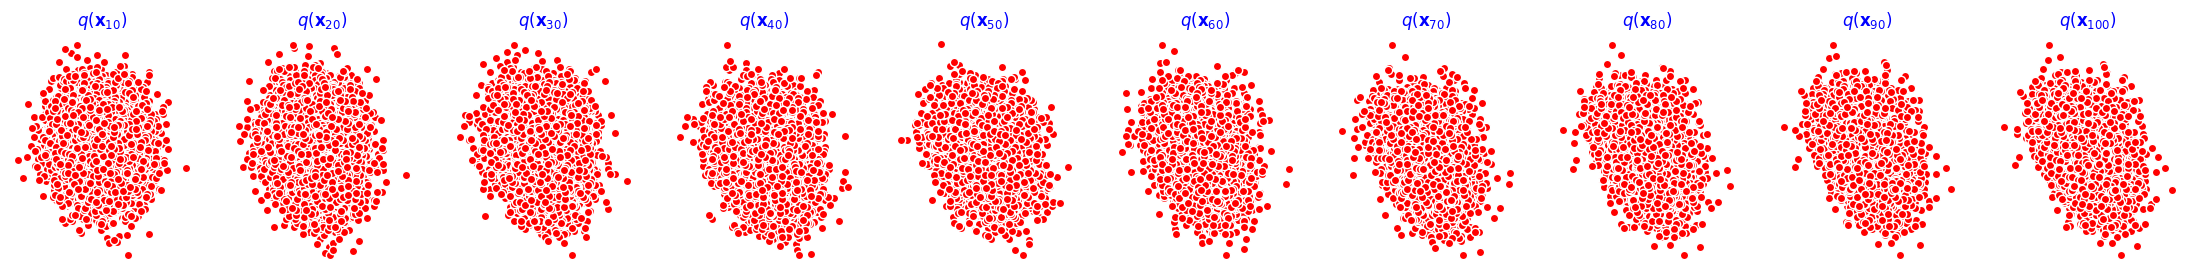

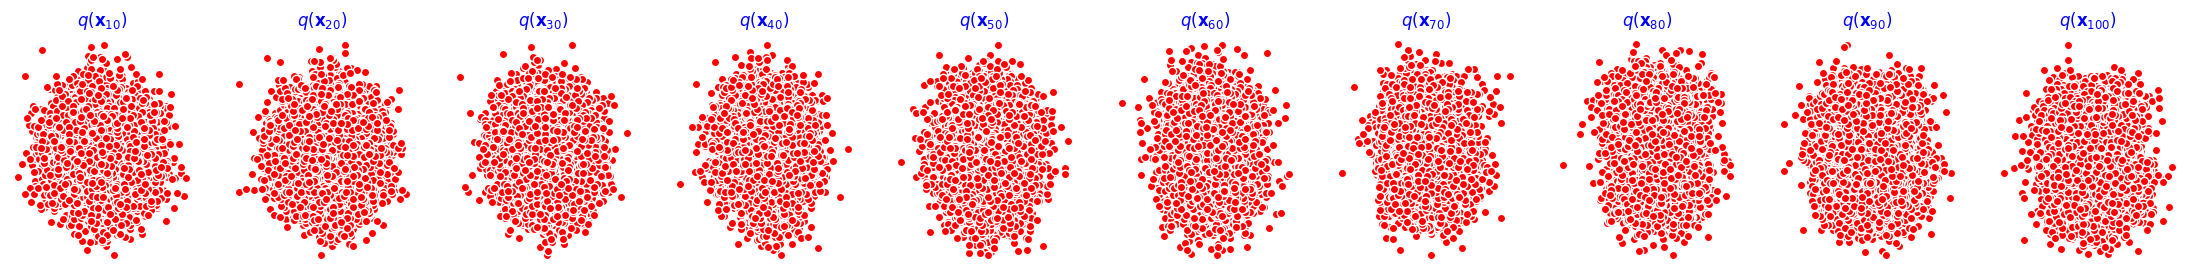

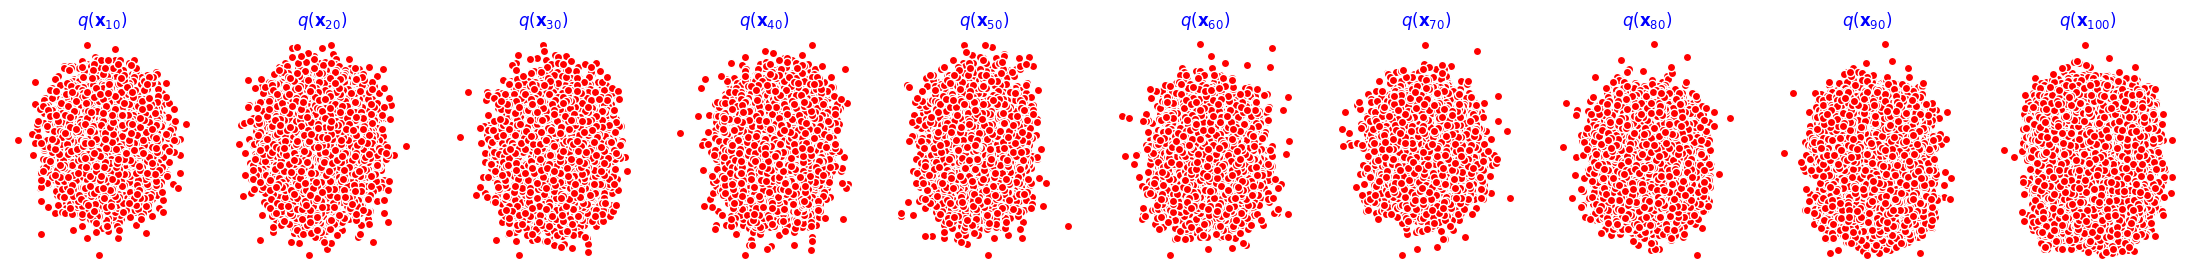

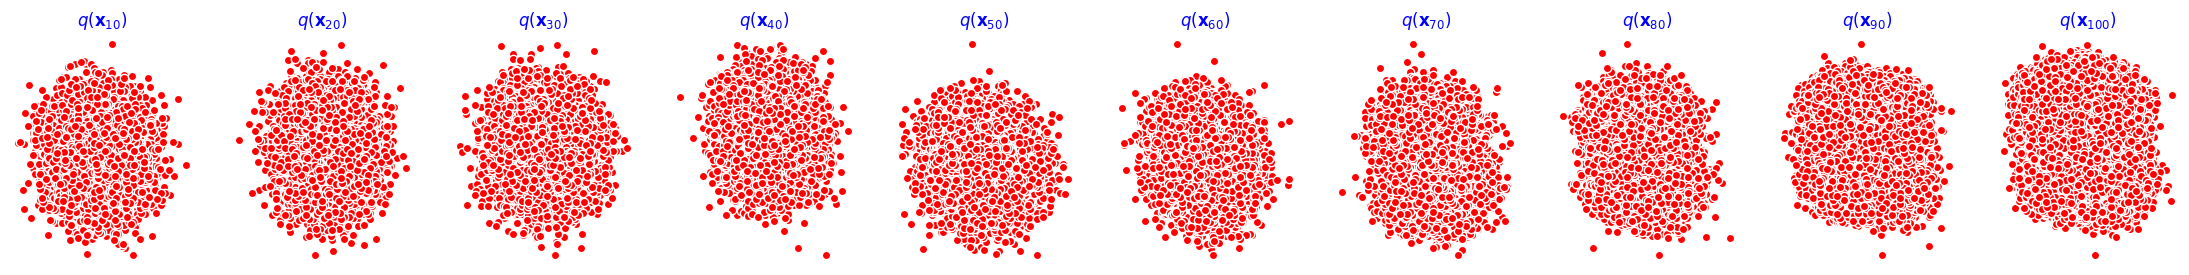

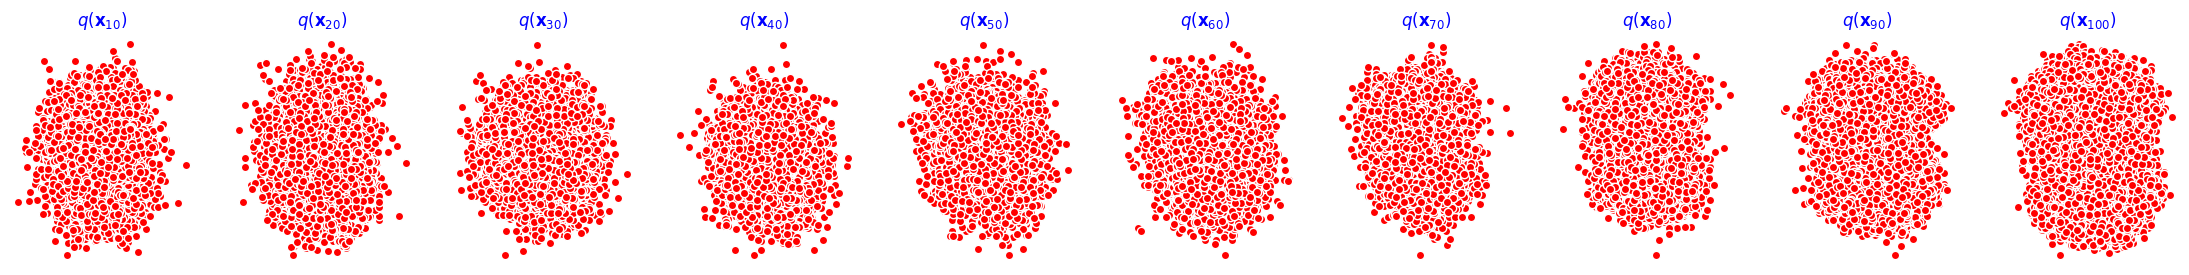

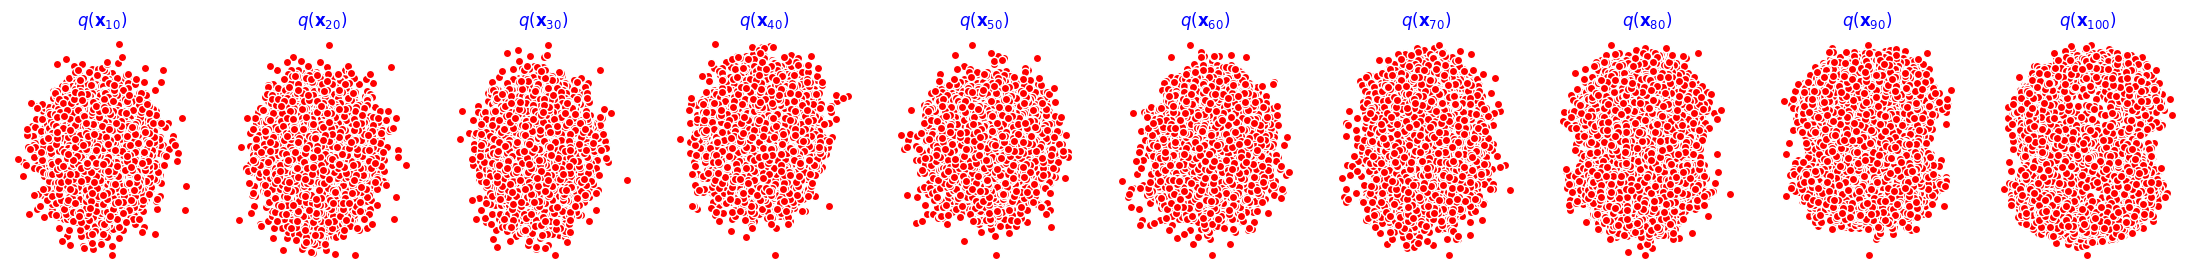

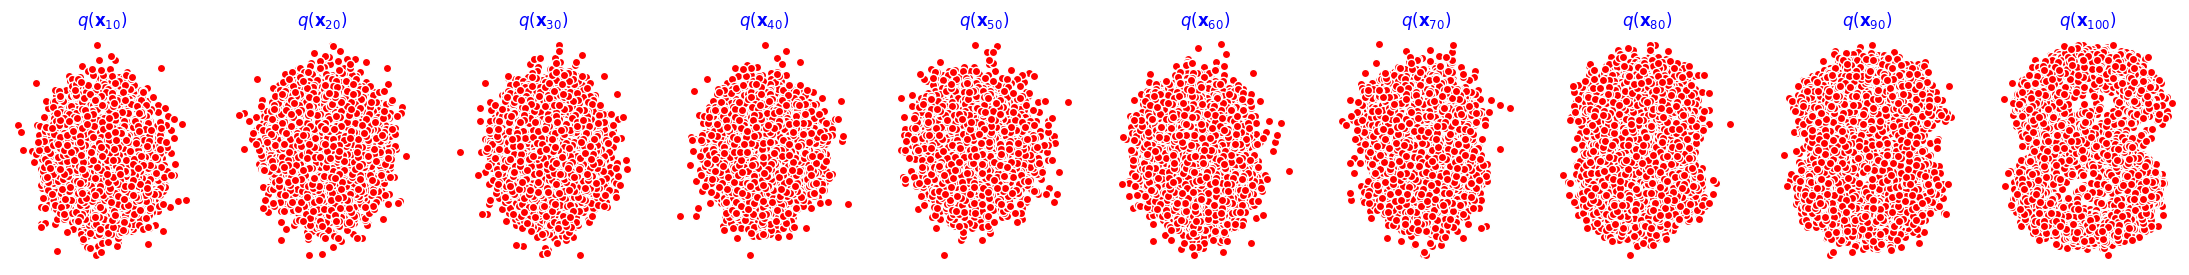

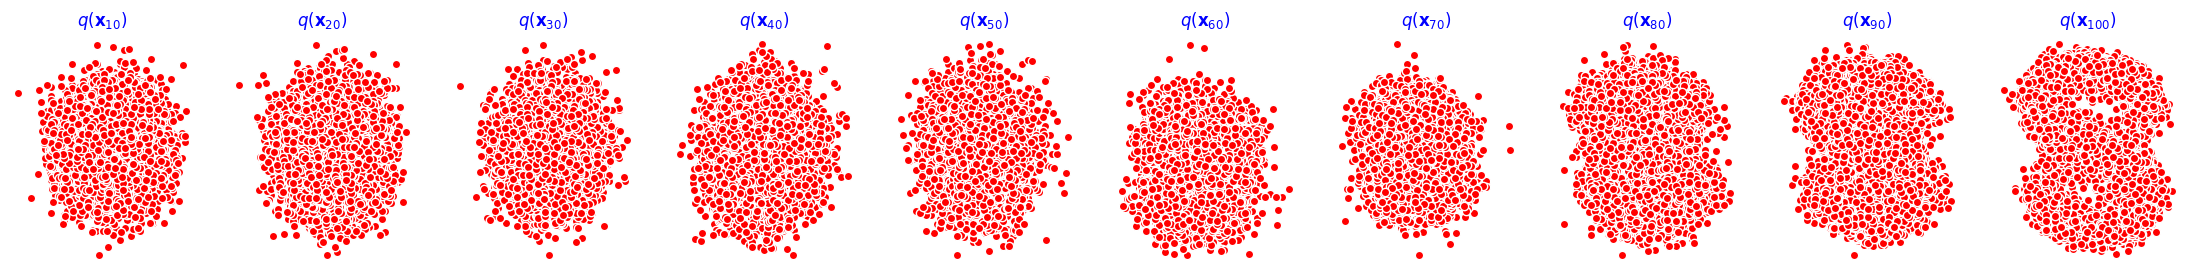

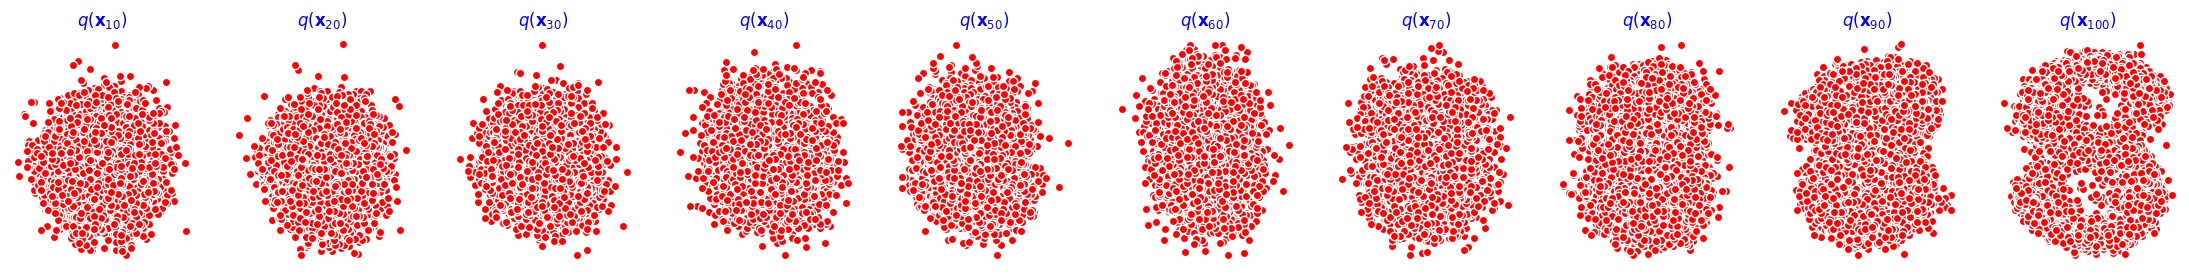

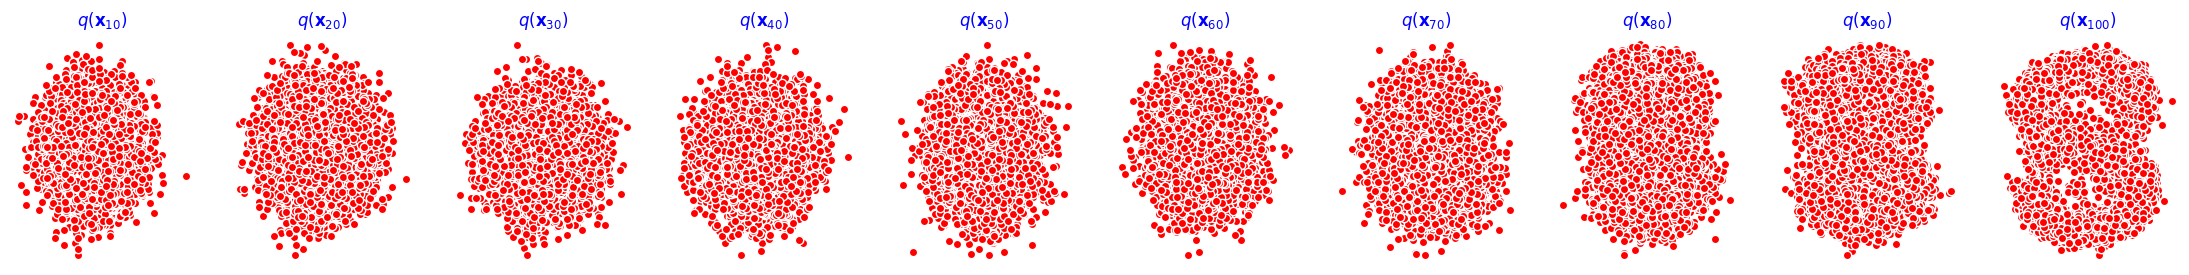

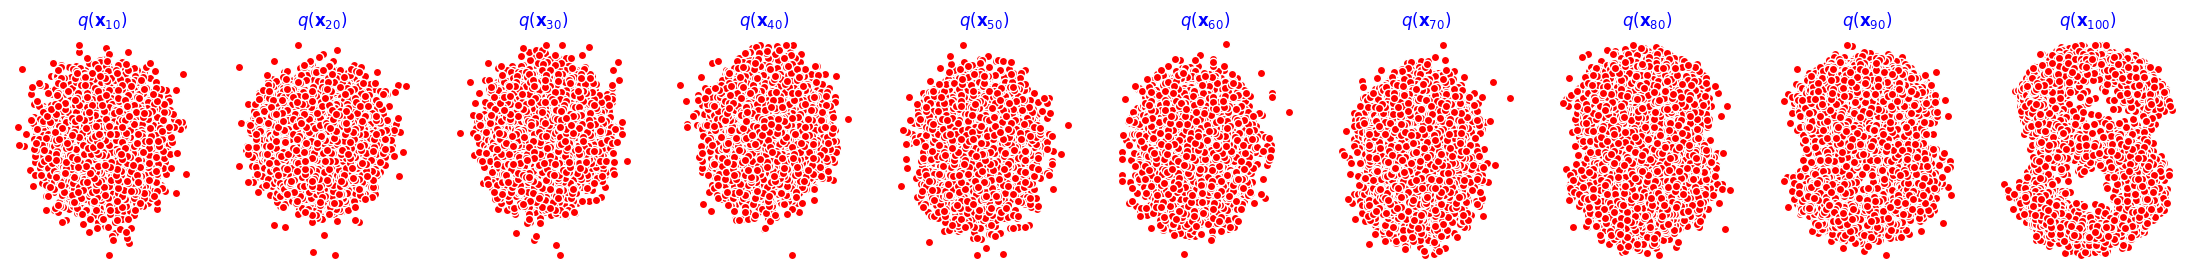

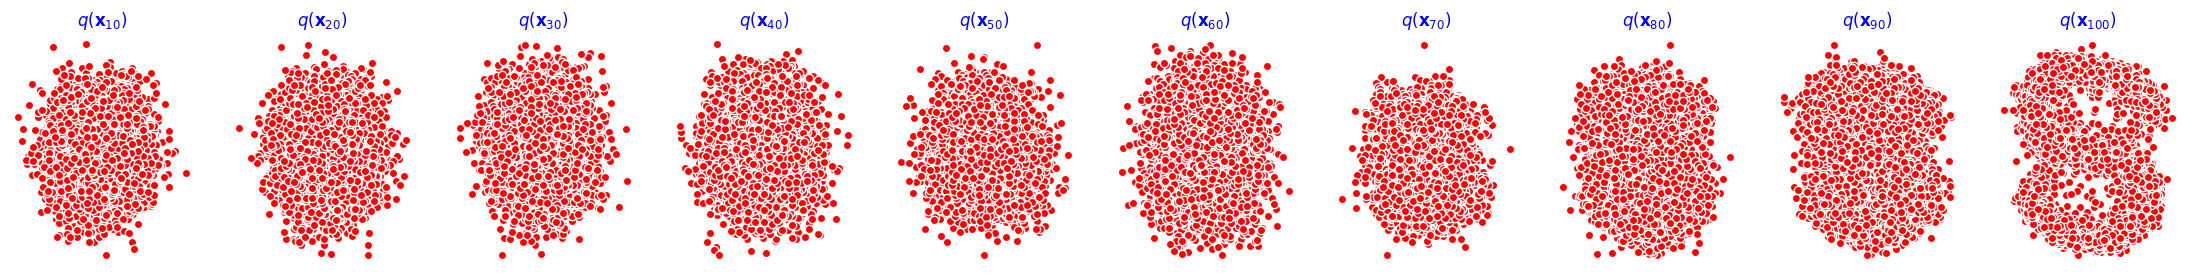

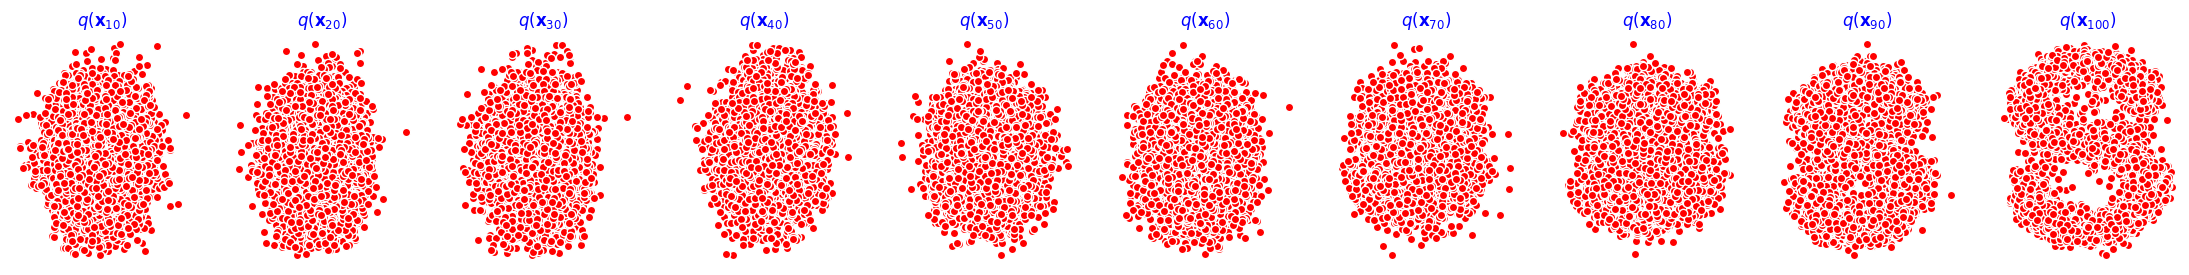

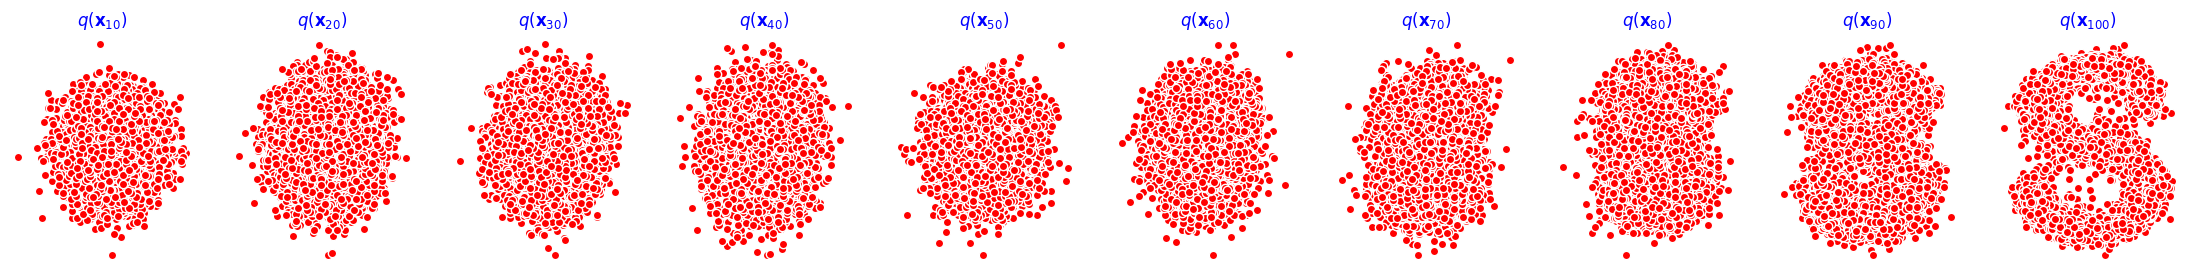

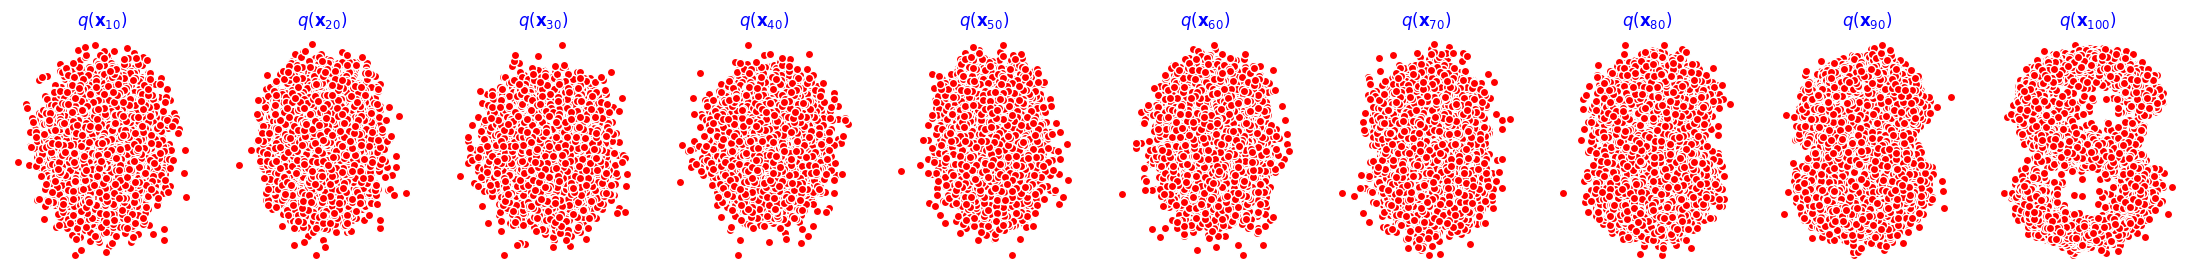

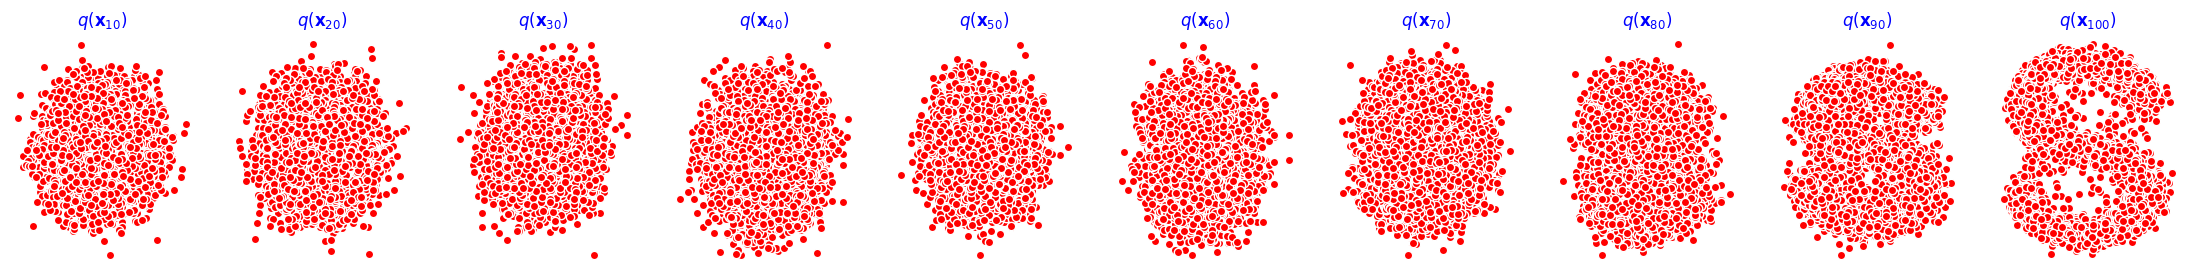

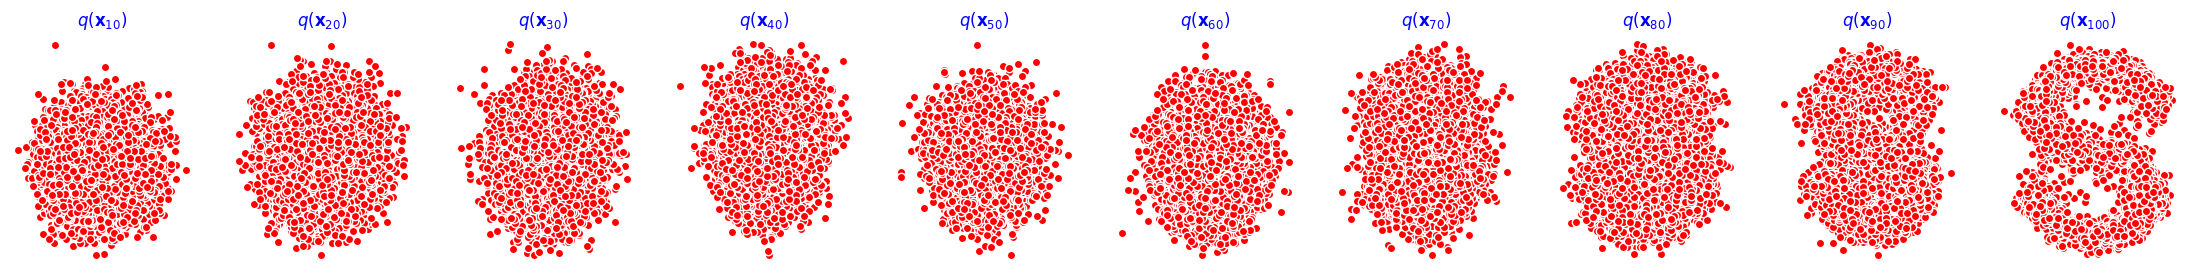

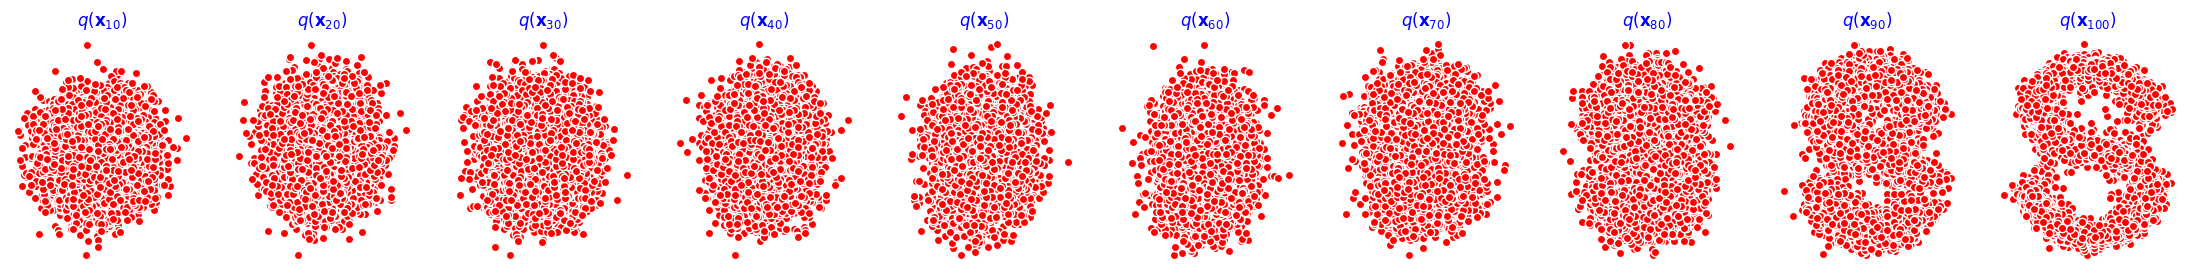

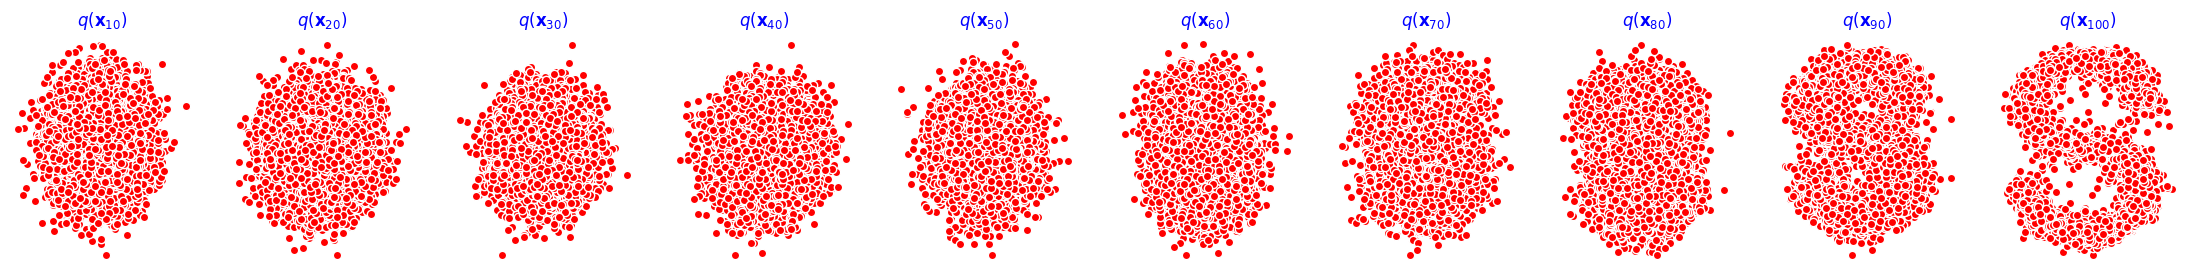

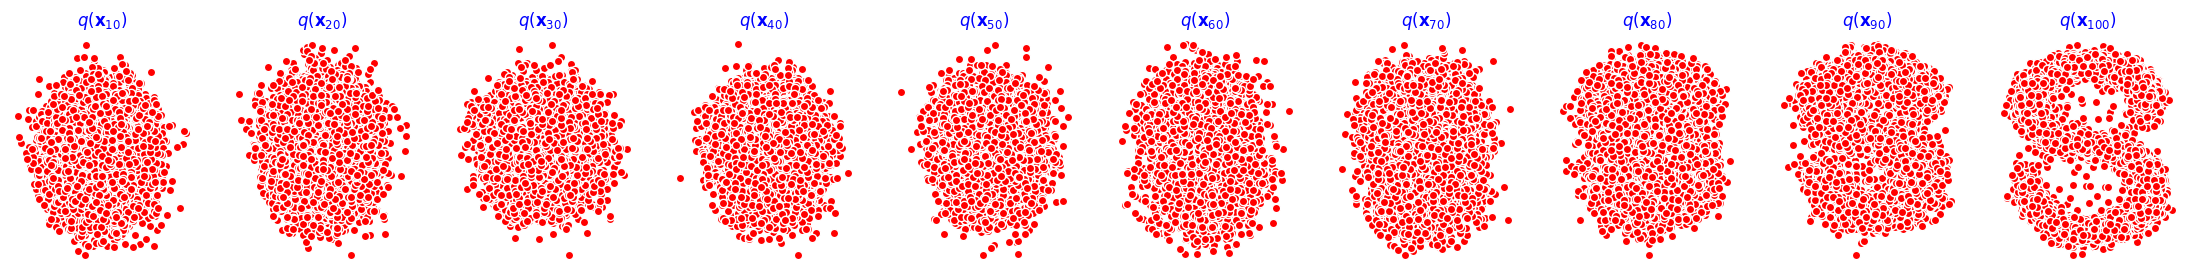

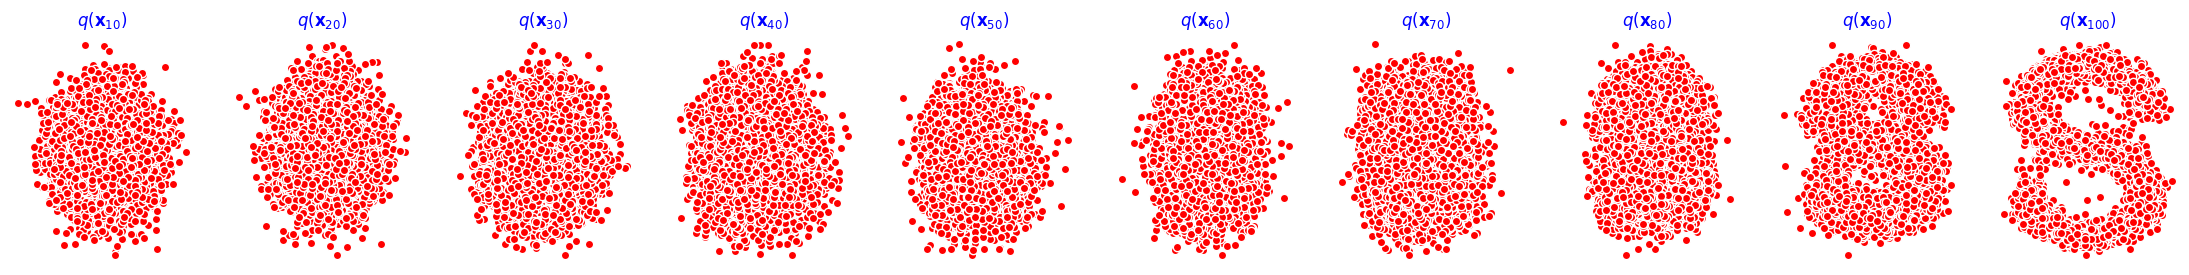

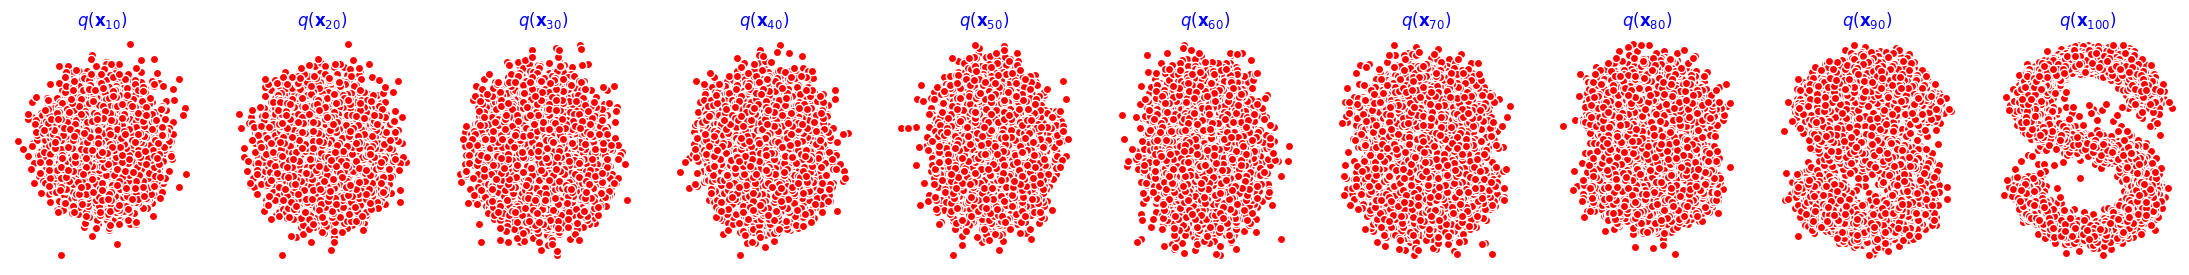

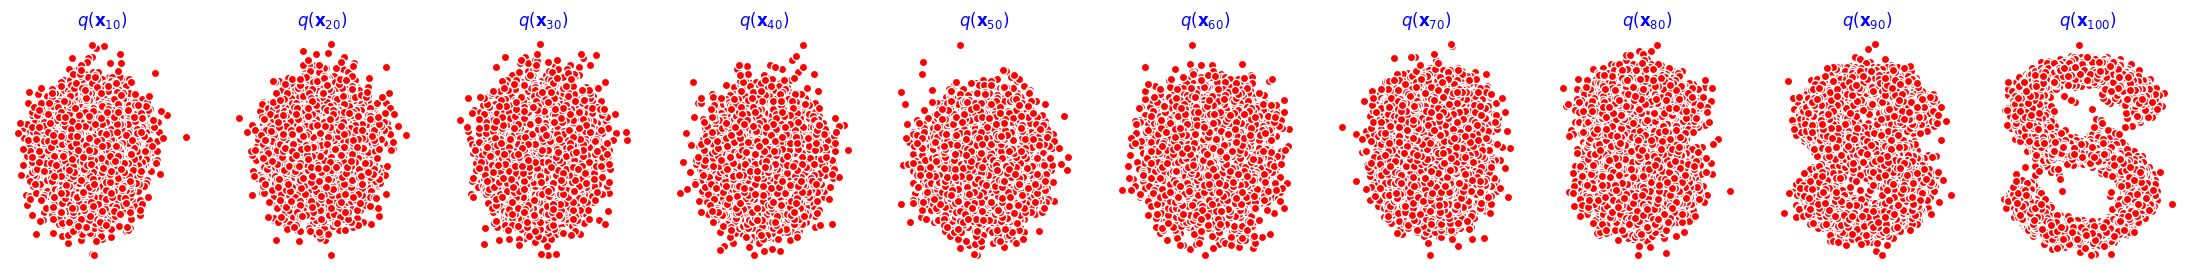

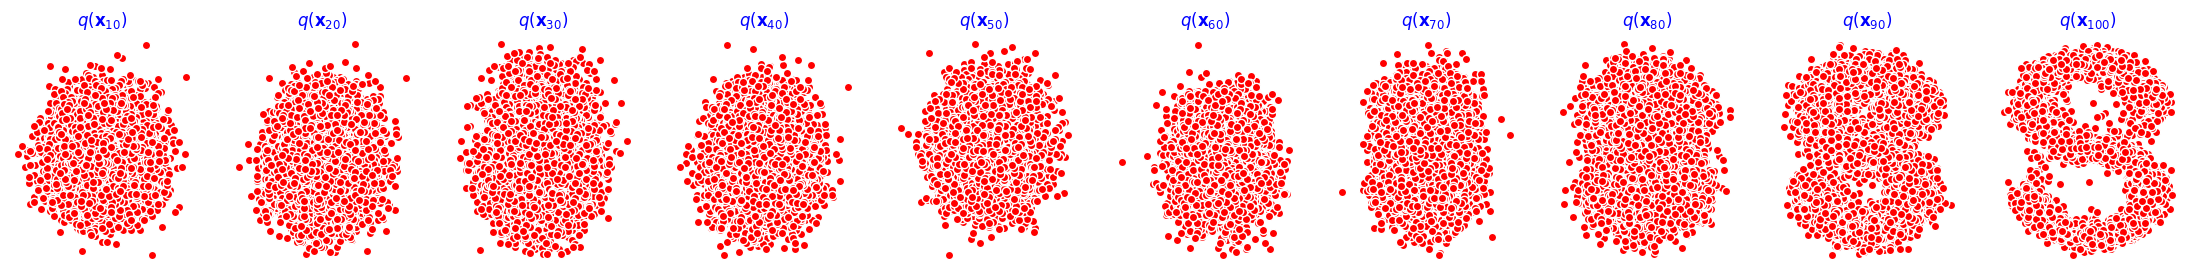

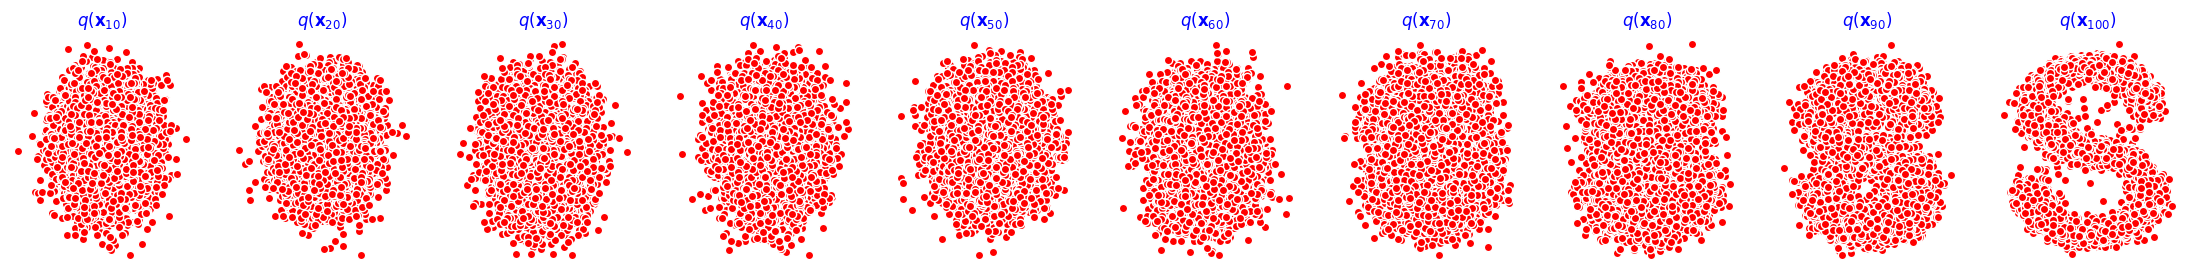

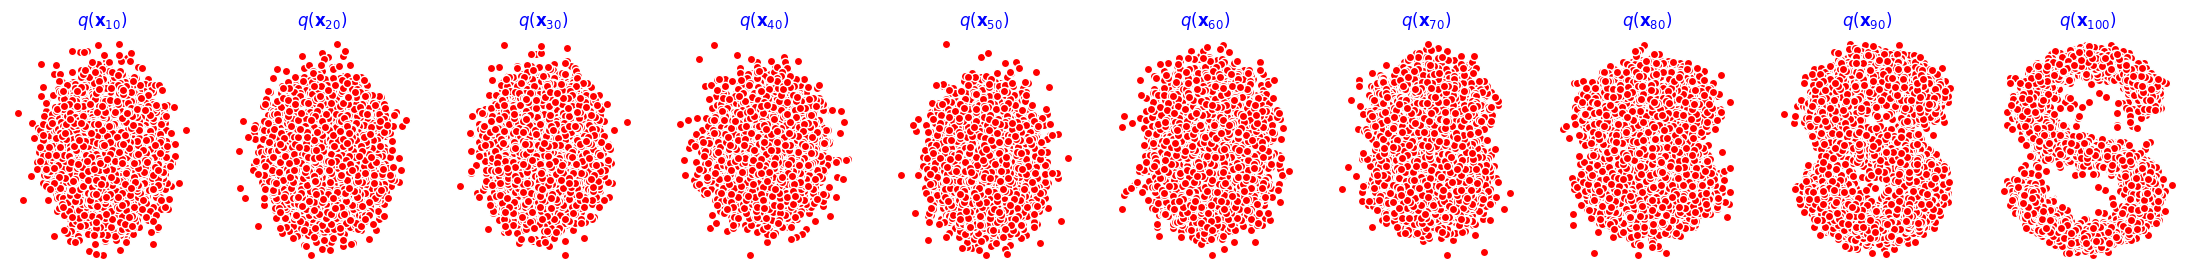

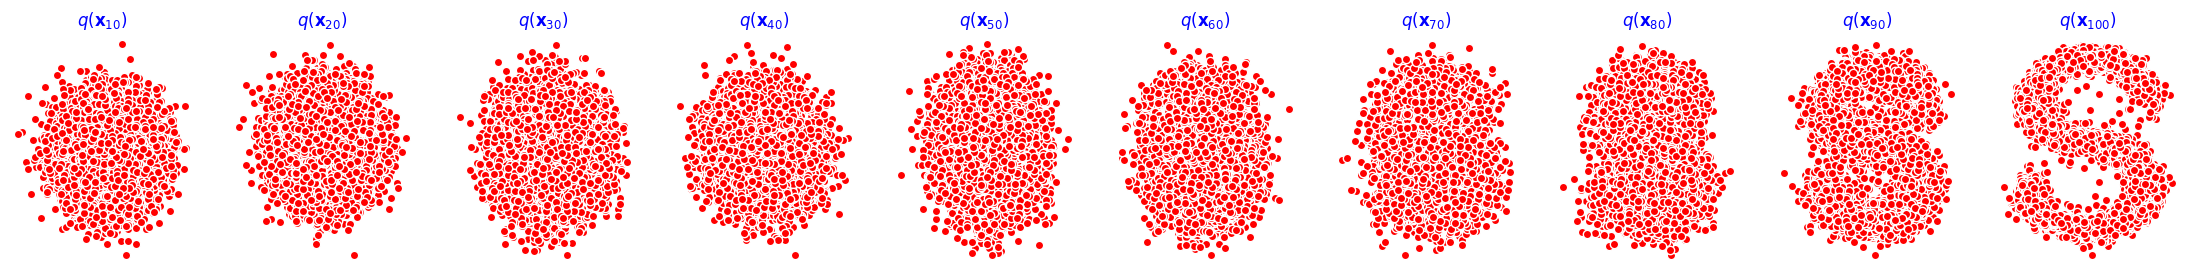

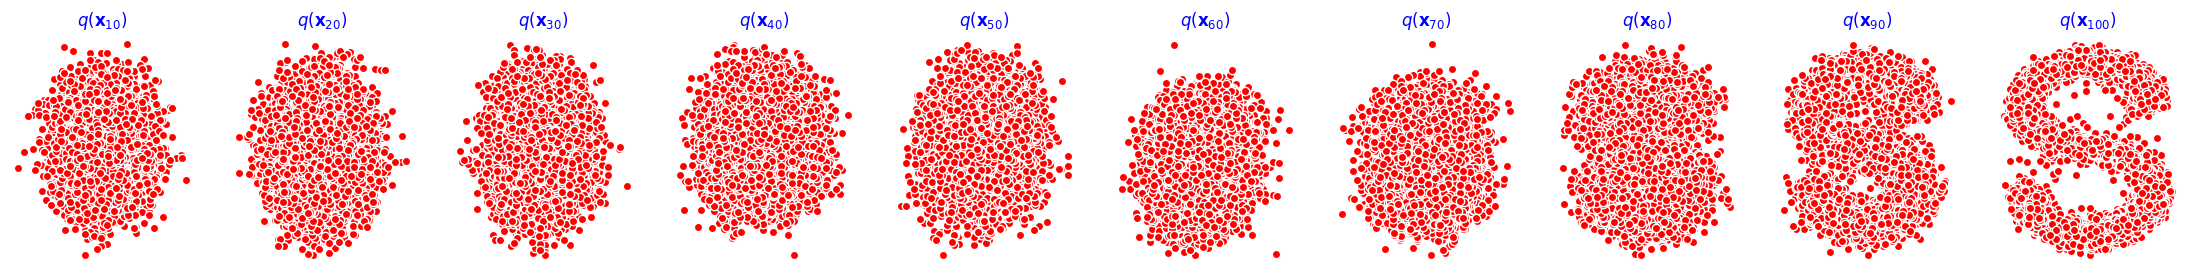

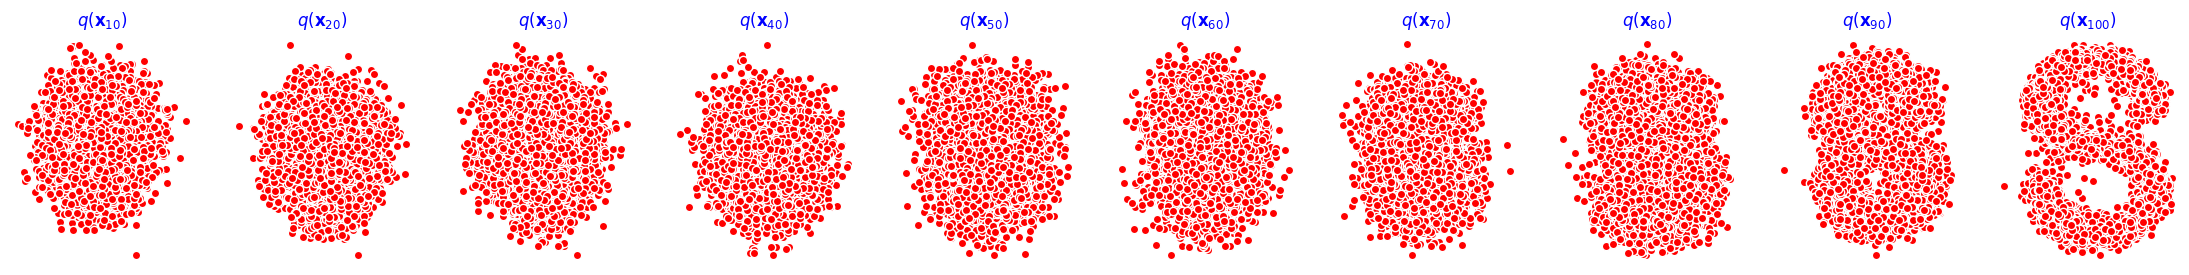

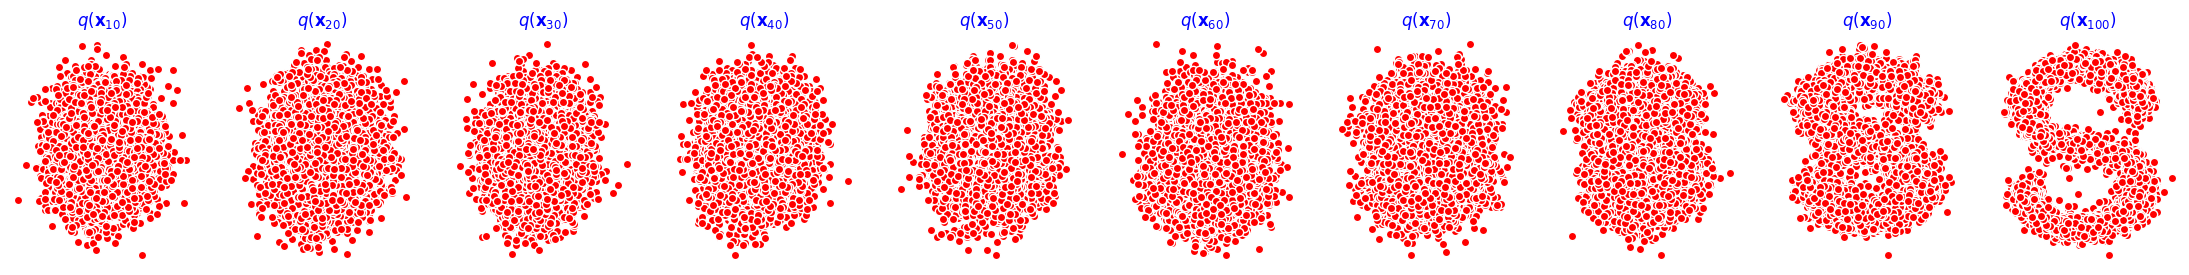

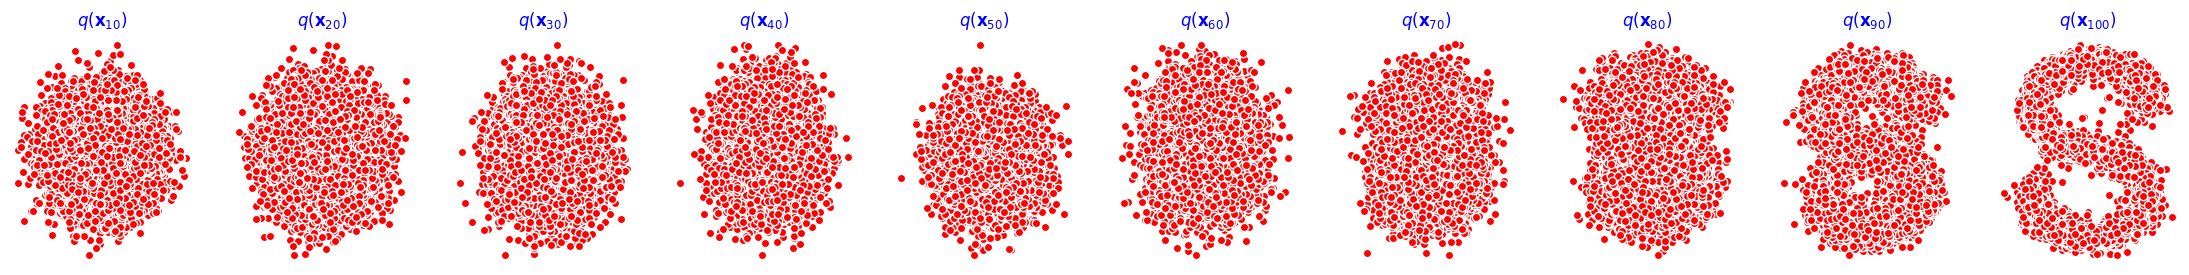

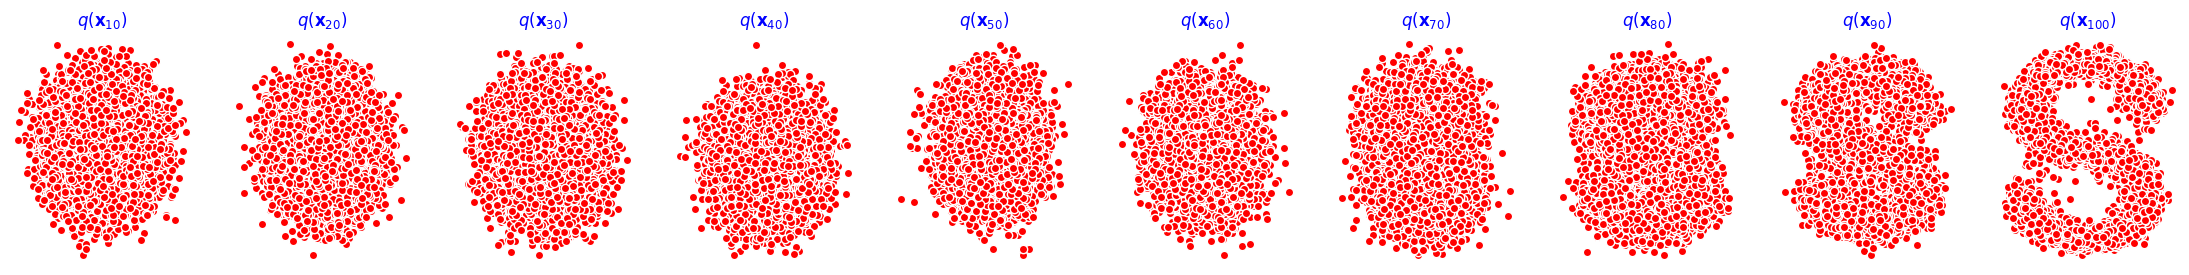

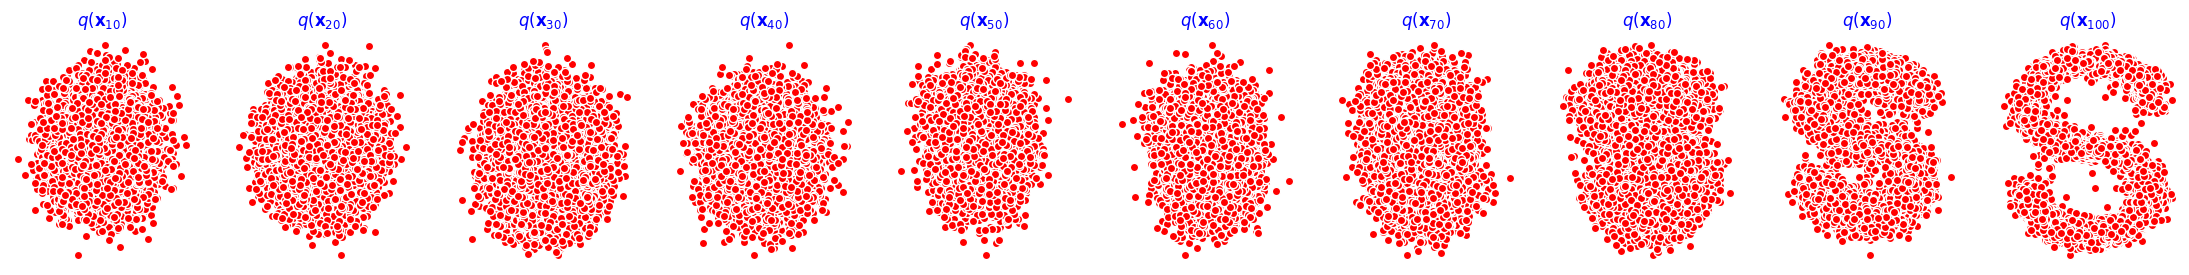

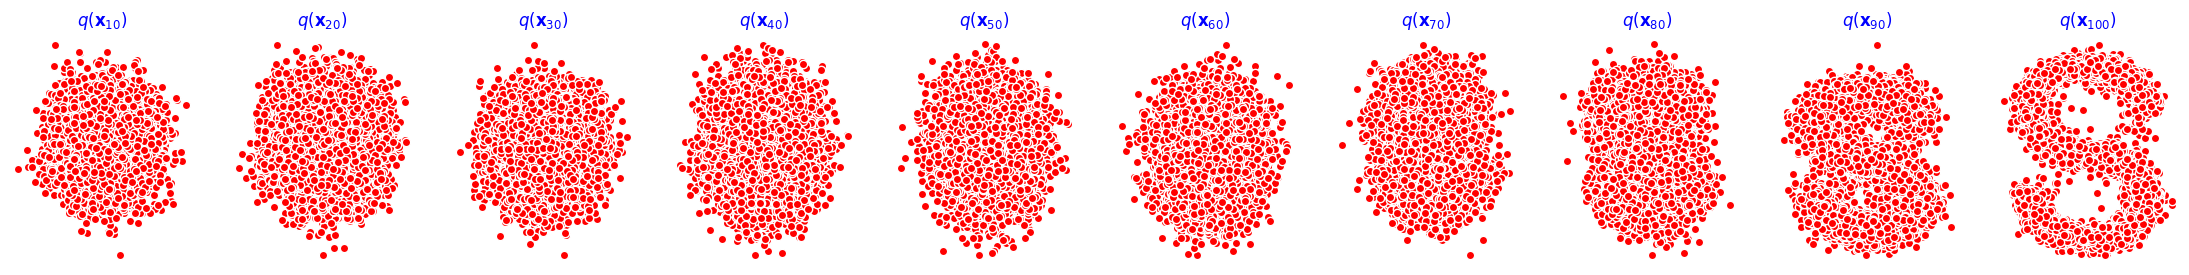

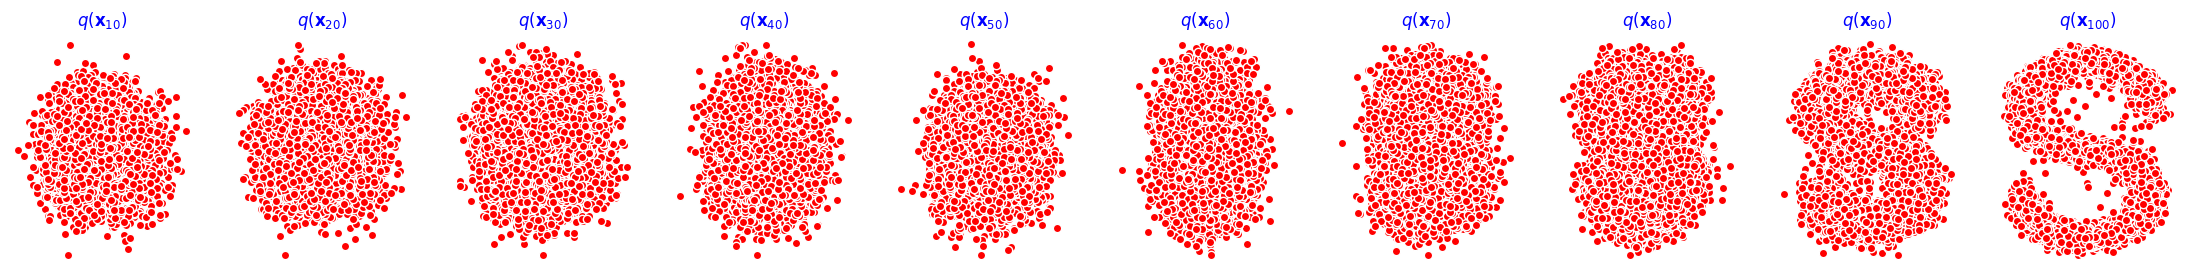

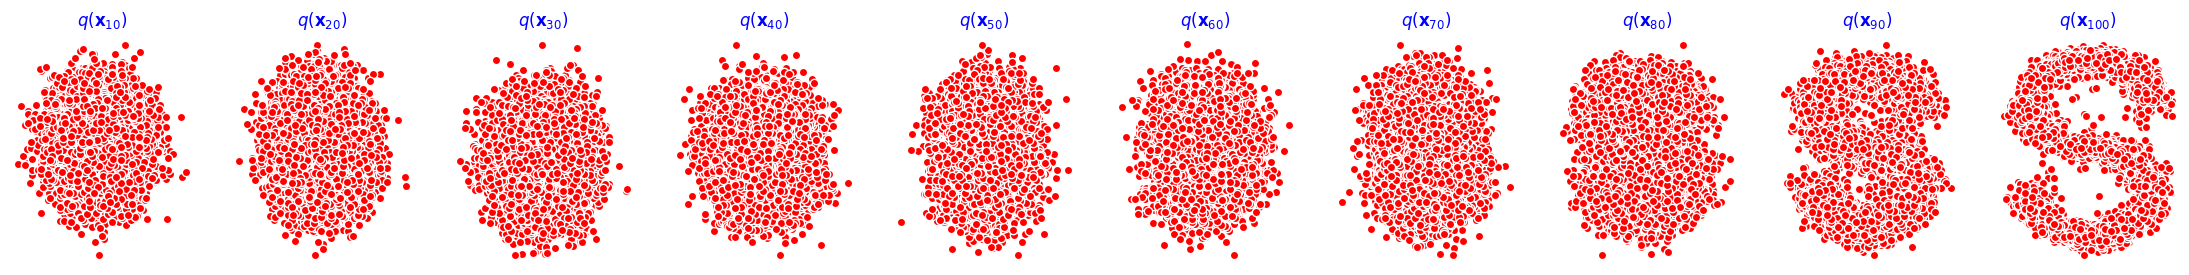

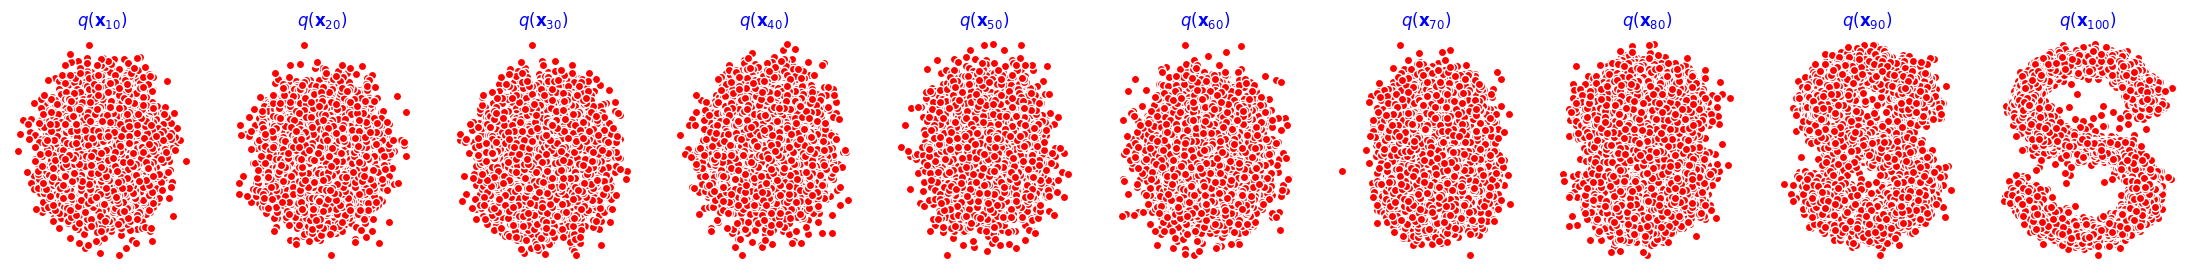

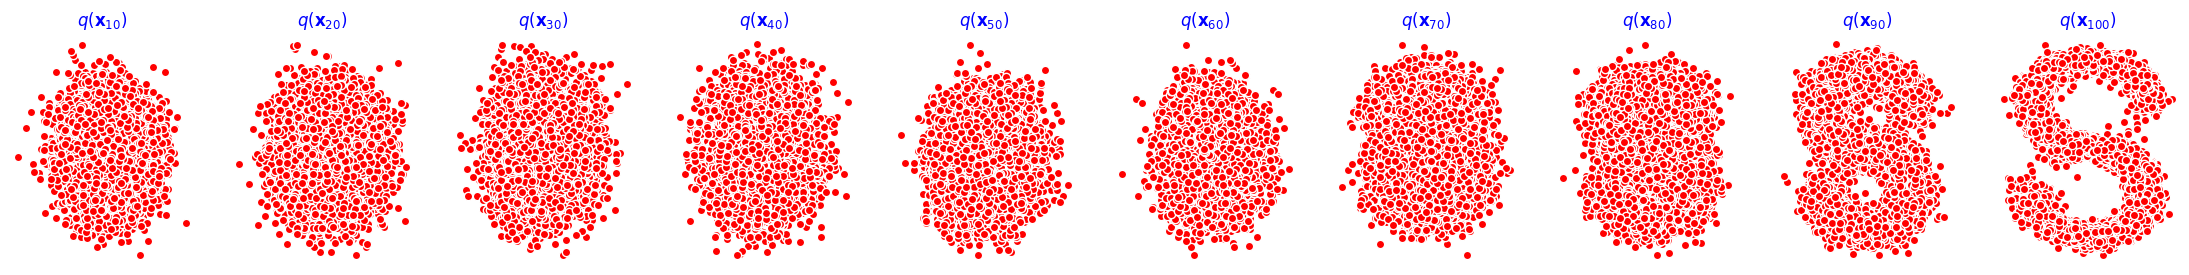

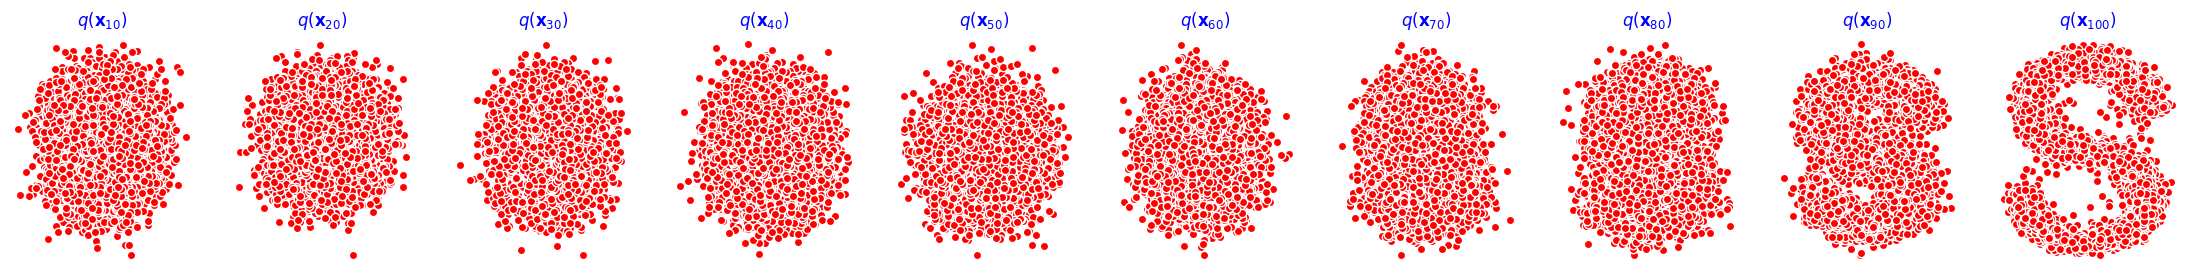

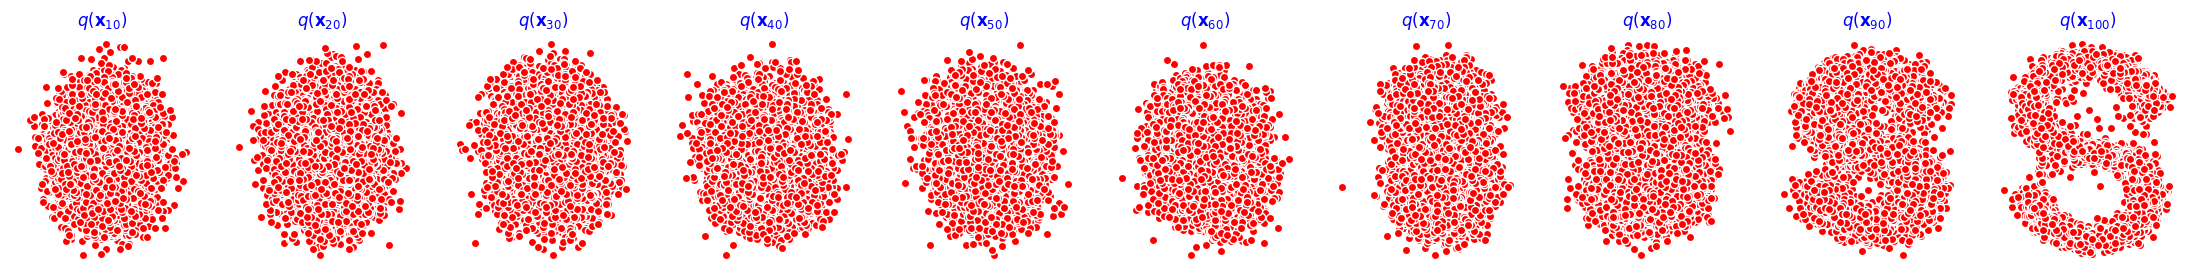

In [8]:
seed = 1234

class EMA():
    """构建一个参数平滑器"""
    def __init__(self,mu=0.01):
        self.mu = mu
        self.shadow = {}
        
    def register(self,name,val):
        self.shadow[name] = val.clone()
        
    def __call__(self,name,x):
        assert name in self.shadow
        new_average = self.mu * x + (1.0 - self.mu) * self.shadow[name]
        self.shadow[name] = new_average.clone()
        return new_average
    
print('Training model...')
batch_size = 128
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
num_epoch = 4000
plt.rc('text',color='blue')

model = MLPDiffusion(num_steps) # 输出维度是2，输入是x和step
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for t in range(num_epoch):
    for idx, batch_x in enumerate(dataloader):
        loss = diffusion_loss_fn(model, batch_x, alphas_bar_sqrt, one_minus_alphas_bar_sqrt, num_steps)
        optimizer.zero_grad()
        loss.backward()
        """
        a very practical numerical-stability safeguard in training diffusion models;
        ensures that no training step is dominated by one unstable batch
        """
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
        optimizer.step()
        
    if (t % 100 == 0):
        print(loss)
        x_seq = p_sample_loop(model, dataset.shape, num_steps, betas, one_minus_alphas_bar_sqrt)
        
        fig,axs = plt.subplots(1, 10, figsize=(28,3))
        for i in range(1, 11):
            cur_x = x_seq[i * 10].detach()
            axs[i - 1].scatter(cur_x[:,0], cur_x[:,1], color='red', edgecolor='white')
            axs[i - 1].set_axis_off()
            axs[i - 1].set_title('$q(\mathbf{x}_{'+str(i*10)+'})$')

9、动画演示扩散过程和逆扩散过程

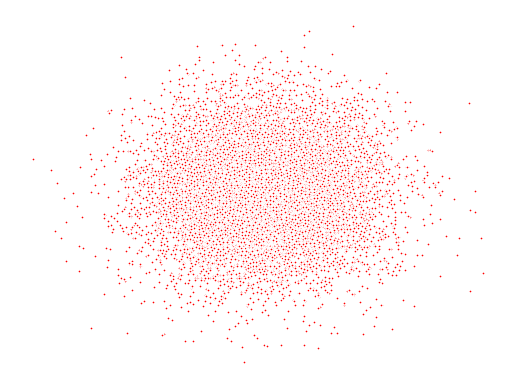

In [9]:
import io
from PIL import Image

imgs = []
for i in range(100):
    plt.clf()
    q_i = q_x(dataset, torch.tensor([i]))
    plt.scatter(q_i[:,0], q_i[:,1], color='red', edgecolor='white', s=5)
    plt.axis('off')
    
    img_buf = io.BytesIO()
    plt.savefig(img_buf, format='png')
    img = Image.open(img_buf)
    imgs.append(img)

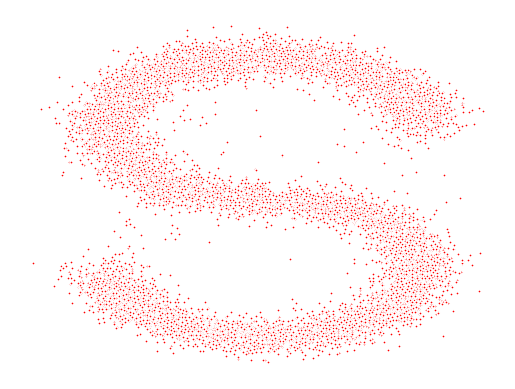

In [10]:
reverse = []
for i in range(100):
    plt.clf()
    cur_x = x_seq[i].detach()
    plt.scatter(cur_x[:,0], cur_x[:,1], color='red', edgecolor='white', s=5);
    plt.axis('off')
    
    img_buf = io.BytesIO()
    plt.savefig(img_buf, format='png')
    img = Image.open(img_buf)
    reverse.append(img)

In [11]:
imgs = imgs +reverse

In [12]:
imgs[0].save("diffusion.gif",format='GIF',append_images=imgs,save_all=True,duration=100,loop=0)